In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta


In [2]:
today = datetime.today().strftime("%Y-%m-%d")
yesterday = (datetime.today() - timedelta(days=1)).strftime("%Y-%m-%d")


In [3]:
# Universo de ETFs
df = pd.read_excel("etfs.xlsx")
df.head()

etfs_list = df["Ticker"].tolist()
etfs = yf.download(etfs_list, start="2010-01-01", end=yesterday, auto_adjust=True)["Close"]

# Benchmark: MSCI World (ACWI)
benchmark = yf.download("ACWI", start="2010-01-01", end=yesterday, auto_adjust=True)["Close"]

# Na segunda etapa fazer um benchmark sintetico usando equal vol do nosso universo 

[*********************100%***********************]  21 of 21 completed
[*********************100%***********************]  1 of 1 completed


# Estrutura do Projeto

Este notebook implementa **duas versões** de uma estratégia de cross-sectional momentum sobre ETFs de países.

| | Estratégia | Sinal | Complexidade |
|---|---|---|---|
| **Estratégia 1** | Momentum Simples | Retorno acumulado bruto ($\sum \log r_t$) | Simples |
| **Estratégia 2** | Sharpe Momentum | Retorno acumulado **normalizado pela volatilidade** | Complexa |

A evolução da simples para a complexa é motivada pelo fato de que dois ETFs com o mesmo retorno acumulado mas com volatilidades diferentes devem ser classificados de maneira distinta. A estratégia complexa captura isso dividindo pelo desvio padrão rolante.

In [4]:
import numpy as np
import seaborn as sns

# ── Segurança: normalizar colunas se MultiIndex ────────────────────────────────
if isinstance(etfs.columns, pd.MultiIndex):
    etfs.columns = etfs.columns.droplevel(0)

# ── Parâmetros base da estratégia ─────────────────────────────────────────────
# NOTA: LOOKBACK e REBAL_FREQ são valores iniciais (defaults).
# Serão sobrescritos pela pré-seleção automática de parâmetros
# executada na célula de otimização, logo após a definição das funções.
LOOKBACK   = 63    # valor inicial — será otimizado
REBAL_FREQ = 21    # valor inicial — será otimizado
QUANTILE   = 0.20  # proporção de ativos por perna (top/bottom 20%)

# ── Limpeza: remove ETFs com dados insuficientes (< 80% de cobertura) ─────────
MIN_COVERAGE = 0.80
etfs_clean   = etfs.dropna(thresh=int(MIN_COVERAGE * len(etfs)), axis=1)

# ── Parâmetros da grade de sensibilidade (serão atualizados após otimização) ──
lookback_grid = [21, 42, 63, 126, 252]
rebal_grid    = [5, 10, 21]

# ── Sub-períodos para análise temporal ────────────────────────────────────────
sub_periodos = {
    "Pré-COVID\n(2010–2019)":  ("2010-01-01", "2019-12-31"),
    "COVID\n(2020–2021)":      ("2020-01-01", "2021-12-31"),
    "Pós-COVID\n(2022–hoje)":  ("2022-01-01", yesterday),
}

# ── Série de benchmark (ACWI) — disponível desde o início ─────────────────────
bmark_series = benchmark.squeeze()
if isinstance(bmark_series, pd.DataFrame):
    bmark_series = bmark_series.iloc[:, 0]

print(f"ETFs no universo (após limpeza): {etfs_clean.shape[1]}")
print(f"Período dos dados: {etfs_clean.index[0].date()} → {etfs_clean.index[-1].date()}")
print(f"Dias úteis disponíveis: {len(etfs_clean)}")
print(f"\nETFs no universo:\n  {sorted(etfs_clean.columns.tolist())}")
print(f"\nParâmetros iniciais → Lookback: {LOOKBACK}d | Rebalanceamento: {REBAL_FREQ}d | Quantil: {int(QUANTILE*100)}%")
print(f"→ LOOKBACK e REBAL_FREQ serão redefinidos pela pré-seleção de parâmetros.")


ETFs no universo (após limpeza): 20
Período dos dados: 2010-01-04 → 2026-04-21
Dias úteis disponíveis: 4099

ETFs no universo:
  ['EIS', 'EPU', 'EWC', 'EWD', 'EWG', 'EWH', 'EWI', 'EWJ', 'EWL', 'EWN', 'EWP', 'EWQ', 'EWS', 'EWU', 'EWW', 'EWY', 'EWZ', 'EZA', 'MCHI', 'THD']

Parâmetros iniciais → Lookback: 63d | Rebalanceamento: 21d | Quantil: 20%
→ LOOKBACK e REBAL_FREQ serão redefinidos pela pré-seleção de parâmetros.


In [5]:
def _compute_metrics(returns_s, rf_annual=0.0):
    """
    Calcula métricas de desempenho anualizadas a partir de uma série de retornos diários.
    """
    ann_return = returns_s.mean() * 252
    ann_vol    = returns_s.std()   * np.sqrt(252)
    sharpe     = (ann_return - rf_annual) / ann_vol if ann_vol > 0 else np.nan

    cumulative  = (1 + returns_s).cumprod()
    rolling_max = cumulative.cummax()
    drawdown    = (cumulative / rolling_max) - 1
    max_dd      = drawdown.min()

    calmar    = ann_return / abs(max_dd) if max_dd != 0 else np.nan
    total_ret = cumulative.iloc[-1] - 1

    return {
        "Retorno Total (%)":      round(total_ret  * 100, 2),
        "Retorno Anualizado (%)": round(ann_return  * 100, 2),
        "Volatilidade Anual (%)": round(ann_vol     * 100, 2),
        "Sharpe Ratio":           round(sharpe,          3),
        "Máximo Drawdown (%)":    round(max_dd      * 100, 2),
        "Calmar Ratio":           round(calmar,          3),
    }


def run_backtest(prices_df, lookback=63, rebal_freq=21, quantile=0.20, rf_annual=0.0, vol_scaled=True):
    """
    Executa o backtest completo da estratégia de momentum cross-sectional.

    Args:
        prices_df  : DataFrame de preços ajustados (datas × ETFs)
        lookback   : janela de lookback em dias úteis
        rebal_freq : frequência de rebalanceamento em dias úteis
        quantile   : proporção de ativos por perna
        rf_annual  : taxa livre de risco anual
        vol_scaled : se True, normaliza o score pela volatilidade rolling (Sharpe Momentum)
                     se False, usa retorno acumulado bruto (Momentum Simples)

    Returns:
        port_returns : pd.Series de retornos diários do portfólio
        metrics      : dict com métricas de desempenho
    """
    simple_ret  = prices_df.pct_change()
    log_ret     = np.log(prices_df / prices_df.shift(1))
    cum_log_ret = log_ret.rolling(lookback).sum()

    if vol_scaled:
        rolling_vol = log_ret.rolling(lookback).std()
        scores_bt   = cum_log_ret / rolling_vol   # Sharpe Momentum (complexo)
    else:
        scores_bt   = cum_log_ret                 # Retorno Acumulado Bruto (simples)

    signal_df = pd.DataFrame(np.nan, index=prices_df.index, columns=prices_df.columns)

    for idx in range(lookback - 1, len(prices_df), rebal_freq):
        date       = prices_df.index[idx]
        day_scores = scores_bt.iloc[idx].dropna()

        if len(day_scores) < 3:
            continue

        long_cutoff  = day_scores.quantile(1 - quantile)
        short_cutoff = day_scores.quantile(quantile)

        longs  = day_scores[day_scores >= long_cutoff].index
        shorts = day_scores[day_scores <= short_cutoff].index

        w = pd.Series(0.0, index=prices_df.columns)
        if len(longs)  > 0: w[longs]  = +1.0 / len(longs)
        if len(shorts) > 0: w[shorts] = -1.0 / len(shorts)

        signal_df.loc[date] = w

    signal_lagged = signal_df.ffill().fillna(0).shift(1).fillna(0)

    port_returns = (simple_ret.fillna(0) * signal_lagged).sum(axis=1)
    port_returns = port_returns.iloc[lookback:]

    metrics = _compute_metrics(port_returns, rf_annual)
    return port_returns, metrics


def build_ranking_snapshot(scores_df, quantile=0.20, date=None):
    """
    Constrói a tabela de classificação para uma data específica.

    Args:
        scores_df : DataFrame de scores por ETF ao longo do tempo
        quantile  : proporção de ativos por perna (ex: 0.20 = top/bottom 20%)
        date      : data para o snapshot (None → última data com dados suficientes)

    Returns:
        ranking   : DataFrame com colunas [Score, Rank, Posição]
        date      : data do snapshot
    """
    if date is None:
        min_etfs  = max(3, int(scores_df.shape[1] * 0.5))
        valid_row = scores_df.notna().sum(axis=1) >= min_etfs
        date      = scores_df[valid_row].index[-1]

    day_scores = scores_df.loc[date].dropna().sort_values(ascending=False)
    n          = len(day_scores)

    long_cutoff  = day_scores.quantile(1 - quantile)
    short_cutoff = day_scores.quantile(quantile)

    ranking = pd.DataFrame({
        "Score": day_scores.round(3),
        "Rank":  range(1, n + 1),
    })
    ranking["Posição"] = "Neutro"
    ranking.loc[ranking["Score"] >= long_cutoff,  "Posição"] = "Long"
    ranking.loc[ranking["Score"] <= short_cutoff, "Posição"] = "Short"

    return ranking, date


print("Funções run_backtest(), _compute_metrics() e build_ranking_snapshot() definidas com sucesso.")
print("  → vol_scaled=True  : Sharpe Momentum (estratégia complexa)")
print("  → vol_scaled=False : Retorno Acumulado Bruto (estratégia simples)")


Funções run_backtest(), _compute_metrics() e build_ranking_snapshot() definidas com sucesso.
  → vol_scaled=True  : Sharpe Momentum (estratégia complexa)
  → vol_scaled=False : Retorno Acumulado Bruto (estratégia simples)


# Pré-Seleção de Parâmetros — Grade Ampla

Antes de fixar `LOOKBACK` e `REBAL_FREQ`, testamos sistematicamente um range amplo de combinações sobre o período completo de dados, usando a **Estratégia Complexa** (Sharpe Momentum, `vol_scaled=True`) como critério de avaliação.

O par com maior **Sharpe Ratio** no período completo é selecionado como parâmetro base e as grades de sensibilidade são atualizadas para sempre incluir esse valor.

> **Atenção:** este passo usa o período completo para seleção — o que pode introduzir leve *in-sample bias* nos parâmetros escolhidos. A análise de sub-períodos (Passo 3B) serve precisamente para verificar se a performance se mantém fora da janela de calibração.


Varredura: L ∈ [5, 120] dias, R ∈ [1, min(L, 60)] dias, passo=1
Combinações válidas: 5420 / 6960
(Filtrando R > L e L*2 ≥ 4099 dias disponíveis)

  500/5420 combinações concluídas...
  1000/5420 combinações concluídas...
  1500/5420 combinações concluídas...
  2000/5420 combinações concluídas...
  2500/5420 combinações concluídas...
  3000/5420 combinações concluídas...
  3500/5420 combinações concluídas...
  4000/5420 combinações concluídas...
  4500/5420 combinações concluídas...
  5000/5420 combinações concluídas...
  5420/5420 combinações concluídas...

  TOP 10 combinações (Estratégia Complexa, período completo):
    Lookback  Rebal  Sharpe  Ret.An.%   MDD%  Calmar
1         18      4   0.425      5.55 -23.34   0.238
2         65     58   0.416      5.07 -28.54   0.177
3         67     58   0.406      4.91 -30.86   0.159
4         66     58   0.389      4.80 -32.90   0.146
5         59     42   0.372      4.74 -42.76   0.111
6         96     51   0.364      4.67 -29.81   0.157
7  

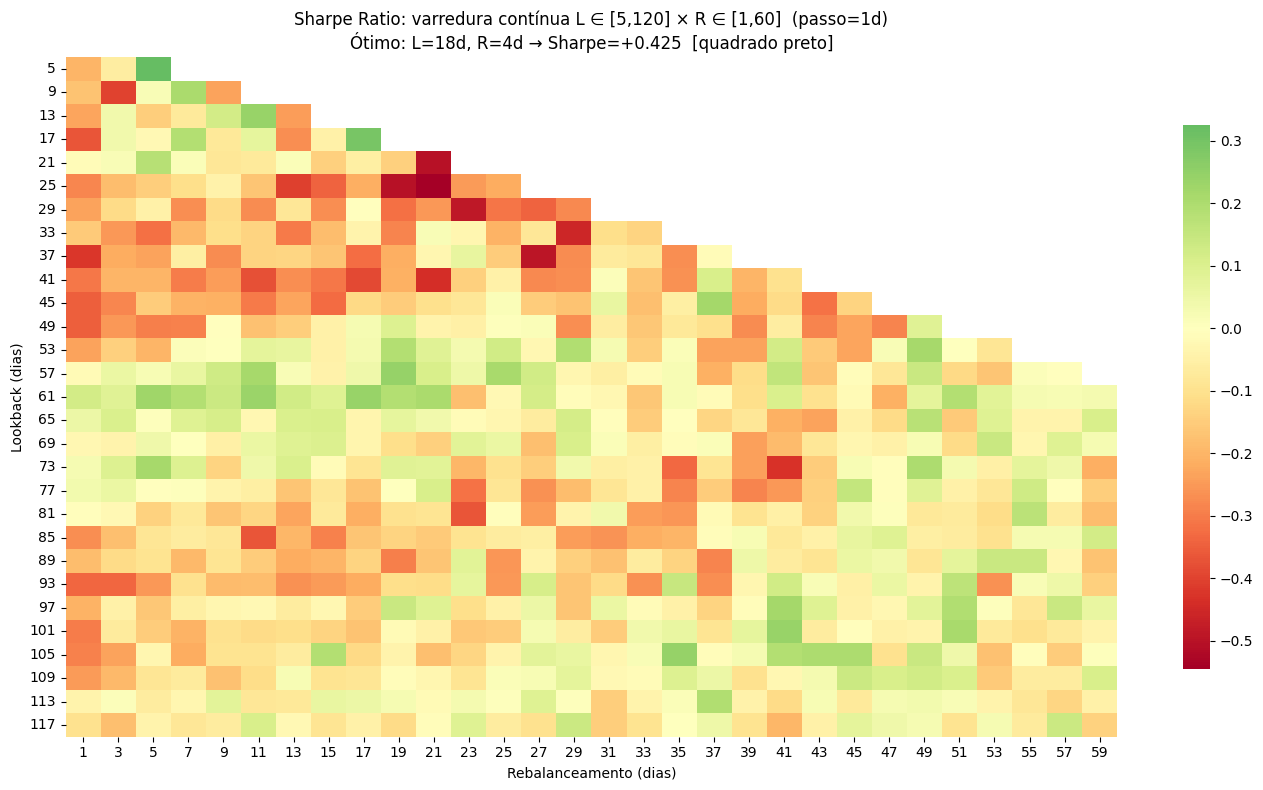

In [24]:
# ── Pré-seleção de parâmetros: varredura contínua ────────────────────────────
# Ajuste os limites e o passo conforme necessário.
# STEP=1 → varredura completa (mais lenta); STEP>1 → mais rápido.

LOOKBACK_MIN = 5      # lookback mínimo em dias úteis
LOOKBACK_MAX = 120    # lookback máximo em dias úteis
REBAL_MAX    = 60    # cap do rebalanceamento (sempre R ≤ L)
STEP         = 1      # granularidade (1 = dia a dia; aumente para acelerar)

lookback_sweep = range(LOOKBACK_MIN, LOOKBACK_MAX + 1, STEP)
rebal_sweep    = range(1, REBAL_MAX + 1, STEP)

# Filtra combinações inválidas: R ≤ L e dados suficientes (L*2 < total de dias)
combinacoes_validas = [
    (L, R)
    for L in lookback_sweep
    for R in rebal_sweep
    if R <= L and L * 2 < len(etfs_clean)
]

n_total   = len(list(lookback_sweep)) * len(list(rebal_sweep))
n_validas = len(combinacoes_validas)
print(f"Varredura: L ∈ [{LOOKBACK_MIN}, {LOOKBACK_MAX}] dias, "
      f"R ∈ [1, min(L, {REBAL_MAX})] dias, passo={STEP}")
print(f"Combinações válidas: {n_validas} / {n_total}")
print(f"(Filtrando R > L e L*2 ≥ {len(etfs_clean)} dias disponíveis)\n")

results_opt = []
for i, (L, R) in enumerate(combinacoes_validas):
    _, m = run_backtest(etfs_clean, lookback=L, rebal_freq=R, quantile=QUANTILE)
    results_opt.append({
        "Lookback": L,
        "Rebal":    R,
        "Sharpe":   m["Sharpe Ratio"],
        "Ret.An.%": m["Retorno Anualizado (%)"],
        "MDD%":     m["Máximo Drawdown (%)"],
        "Calmar":   m["Calmar Ratio"],
    })
    if (i + 1) % 500 == 0 or (i + 1) == n_validas:
        print(f"  {i+1}/{n_validas} combinações concluídas...")

# ── Ranking e seleção ──────────────────────────────────────────────────────────
results_opt_df = (
    pd.DataFrame(results_opt)
    .sort_values("Sharpe", ascending=False)
    .reset_index(drop=True)
)
results_opt_df.index += 1  # rank a partir de 1

best_row   = results_opt_df.iloc[0]
LOOKBACK   = int(best_row["Lookback"])
REBAL_FREQ = int(best_row["Rebal"])

print(f"\n{'='*60}")
print(f"  TOP 10 combinações (Estratégia Complexa, período completo):")
print(f"{'='*60}")
print(results_opt_df.head(10).to_string())

print(f"\n{'='*60}")
print(f"  PARÂMETROS SELECIONADOS (melhor Sharpe Ratio):")
print(f"    Lookback        : {LOOKBACK} dias úteis")
print(f"    Rebalanceamento : {REBAL_FREQ} dias úteis")
print(f"    Sharpe Ratio    : {best_row['Sharpe']:+.3f}")
print(f"    Ret. Anualizado : {best_row['Ret.An.%']:+.1f}%")
print(f"    Máx. Drawdown   : {best_row['MDD%']:.1f}%")
print(f"{'='*60}")

# ── Atualiza as grades de sensibilidade para incluir o ponto ótimo ────────────
lookback_grid = sorted(set([21, 42, 63, 126, 252] + [LOOKBACK]))
rebal_grid    = sorted(set([5, 10, 21] + [REBAL_FREQ]))
print(f"\nGrades de sensibilidade atualizadas:")
print(f"  Lookbacks       : {lookback_grid}")
print(f"  Rebalanceamentos: {rebal_grid}")

# ── Heatmap da varredura (amostra se muitas combinações) ──────────────────────
# Para visualização: preenche uma grade 2D com os Sharpes obtidos
heat_L = sorted({r["Lookback"] for r in results_opt})
heat_R = sorted({r["Rebal"]    for r in results_opt})
heat_data = pd.DataFrame(index=heat_L, columns=heat_R, dtype=float)
heat_data.index.name = "Lookback (dias)"
for r in results_opt:
    heat_data.loc[r["Lookback"], r["Rebal"]] = r["Sharpe"]

# Se a grade for muito grande, reduz para visualização (~20×20 no máximo)
MAX_TICKS = 25
if len(heat_L) > MAX_TICKS:
    step_L = max(1, len(heat_L) // MAX_TICKS)
    heat_L_plot = heat_L[::step_L]
else:
    heat_L_plot = heat_L
if len(heat_R) > MAX_TICKS:
    step_R = max(1, len(heat_R) // MAX_TICKS)
    heat_R_plot = heat_R[::step_R]
else:
    heat_R_plot = heat_R

heat_plot = heat_data.loc[heat_L_plot, heat_R_plot].astype(float)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    heat_plot, ax=ax,
    annot=len(heat_L_plot) * len(heat_R_plot) <= 300,
    fmt=".2f",
    cmap="RdYlGn", center=0,
    linewidths=0.0 if len(heat_L_plot) > 15 else 0.5,
    cbar_kws={"shrink": 0.8},
    mask=heat_plot.isna(),
)
# Marca o ponto ótimo se estiver na grade plotada
if LOOKBACK in heat_L_plot and REBAL_FREQ in heat_R_plot:
    opt_row = heat_L_plot.index(LOOKBACK)
    opt_col = heat_R_plot.index(REBAL_FREQ)
    ax.add_patch(plt.Rectangle(
        (opt_col, opt_row), 1, 1,
        fill=False, edgecolor="black", linewidth=3.0
    ))
ax.set_title(
    f"Sharpe Ratio: varredura contínua L ∈ [{LOOKBACK_MIN},{LOOKBACK_MAX}] × R ∈ [1,{REBAL_MAX}]  (passo={STEP}d)\n"
    f"Ótimo: L={LOOKBACK}d, R={REBAL_FREQ}d → Sharpe={best_row['Sharpe']:+.3f}  [quadrado preto]",
    fontsize=12
)
ax.set_xlabel("Rebalanceamento (dias)", fontsize=10)
ax.set_ylabel("Lookback (dias)", fontsize=10)
plt.tight_layout()
plt.show()


---

# Estratégia 1 (Simples) — Momentum por Retorno Acumulado Bruto

## Lógica da Estratégia Simples

O sinal é o **retorno acumulado bruto** sobre a janela de lookback, sem normalização:

$$\text{score}_{\text{simples}}(i,\, t) = \sum_{k=t-L}^{t} \log r_k(i)$$

Isso é equivalente a $\log\!\left(\frac{P_t}{P_{t-L}}\right)$, ou seja, o log-retorno total no período.

**Intuição:** ETFs que subiram mais no passado recente ficam no topo do ranking → long. ETFs que caíram mais ficam no bottom → short. Simples e direto.

## Diferença em Relação à Estratégia Complexa

| | Estratégia 1 (Simples) | Estratégia 2 (Complexa) |
|---|---|---|
| **Sinal** | $\sum \log r_t$ | $\sum \log r_t \,/\, \sigma_{\text{rolling}}$ |
| **Normaliza por vol?** | ✗ Não | ✓ Sim |
| **Problema** | ETF com retorno 5% e vol 20% = ETF com retorno 5% e vol 2% | Corrigido |
| **Vantagem** | Simples, interpretável | Ranking mais justo entre ativos com volatilidades distintas |

A estratégia simples trata ativos com o mesmo retorno como iguais, **ignorando o risco assumido** para gerar esse retorno. A versão complexa corrige isso.

## Parâmetros

| Parâmetro | Valor |
|---|---|
| Lookback ($L$) | 63 dias úteis |
| Rebalanceamento | 21 dias úteis |
| Quantil | 20% |

In [6]:
# ── Backtest da Estratégia Simples (vol_scaled=False) ─────────────────────────
simple_port_returns, simple_metrics = run_backtest(
    prices_df  = etfs_clean,
    lookback   = LOOKBACK,
    rebal_freq = REBAL_FREQ,
    quantile   = QUANTILE,
    rf_annual  = 0.0,
    vol_scaled = False,   # sinal = retorno acumulado bruto (sem divisão por vol)
)

# ── Métricas da Estratégia Simples ────────────────────────────────────────────
simple_df = pd.DataFrame({"Estratégia 1 (Simples)": simple_metrics}).T

print("=" * 65)
print("    DESEMPENHO — Estratégia 1 (Simples) | Período Completo")
print("=" * 65)
print(simple_df.to_string())
print()
print(f"Parâmetros: Lookback={LOOKBACK}d | Rebalanceamento={REBAL_FREQ}d | Quantil={int(QUANTILE*100)}%")
print("\n→ Comparação Simples vs Complexa vs ACWI aparece após o backtest da Estratégia 2.")

    DESEMPENHO — Estratégia 1 (Simples) | Período Completo
                        Retorno Total (%)  Retorno Anualizado (%)  Volatilidade Anual (%)  Sharpe Ratio  Máximo Drawdown (%)  Calmar Ratio
Estratégia 1 (Simples)             -50.07                   -3.27                   14.59        -0.224               -68.56        -0.048

Parâmetros: Lookback=63d | Rebalanceamento=21d | Quantil=20%

→ Comparação Simples vs Complexa vs ACWI aparece após o backtest da Estratégia 2.


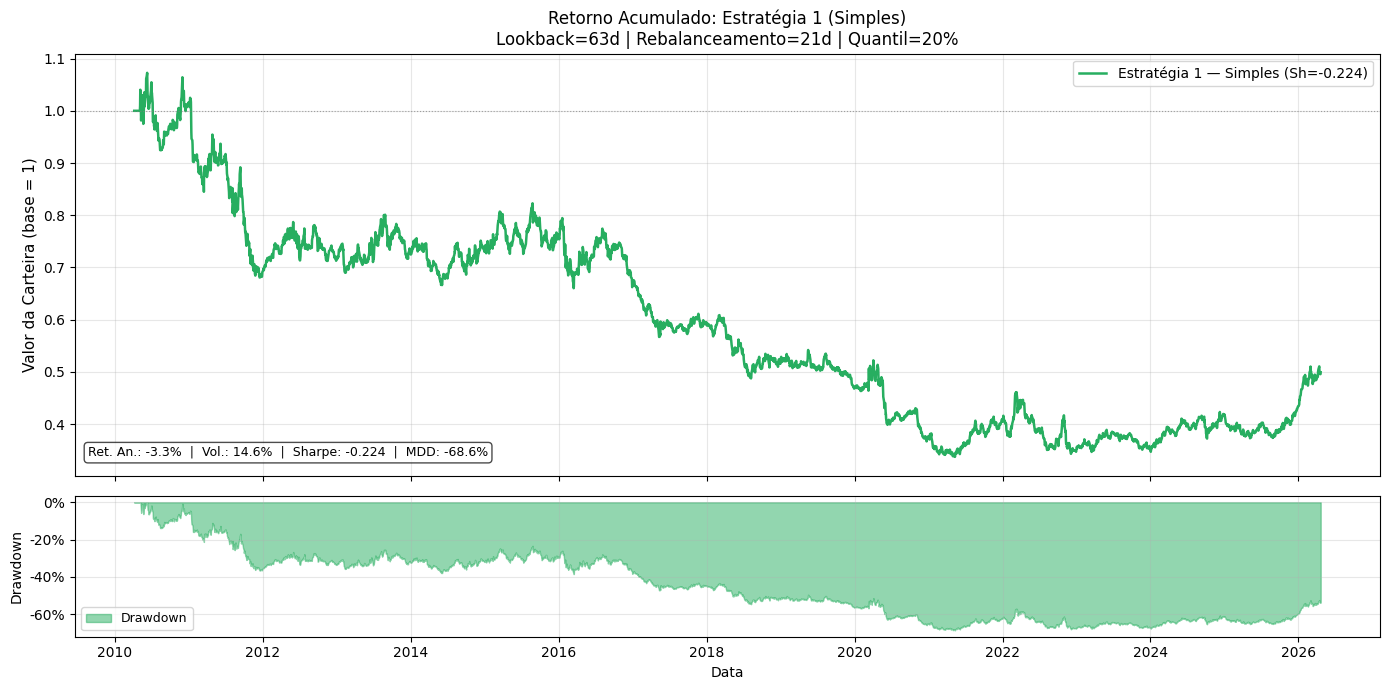

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={"height_ratios": [3, 1]}, sharex=True)

cumret_simple = (1 + simple_port_returns).cumprod()

axes[0].plot(cumret_simple.index, cumret_simple.values,
             label=f"Estratégia 1 — Simples (Sh={simple_metrics['Sharpe Ratio']:.3f})",
             color="#27ae60", linewidth=1.8)
axes[0].axhline(1, color="grey", linewidth=0.8, linestyle=":", alpha=0.7)
axes[0].set_ylabel("Valor da Carteira (base = 1)", fontsize=11)
axes[0].set_title(
    "Retorno Acumulado: Estratégia 1 (Simples)\n"
    f"Lookback={LOOKBACK}d | Rebalanceamento={REBAL_FREQ}d | Quantil={int(QUANTILE*100)}%",
    fontsize=12
)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

txt = (
    f"Ret. An.: {simple_metrics['Retorno Anualizado (%)']:+.1f}%  |  "
    f"Vol.: {simple_metrics['Volatilidade Anual (%)']:.1f}%  |  "
    f"Sharpe: {simple_metrics['Sharpe Ratio']:.3f}  |  "
    f"MDD: {simple_metrics['Máximo Drawdown (%)']:.1f}%"
)
axes[0].text(0.01, 0.04, txt, transform=axes[0].transAxes, fontsize=9,
             verticalalignment="bottom",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

rolling_max_s = cumret_simple.cummax()
drawdown_s    = (cumret_simple / rolling_max_s) - 1

axes[1].fill_between(drawdown_s.index, drawdown_s.values, 0,
                     color="#27ae60", alpha=0.5, label="Drawdown")
axes[1].set_ylabel("Drawdown", fontsize=10)
axes[1].set_xlabel("Data", fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.show()

In [8]:
# ── Scores de momentum simples para snapshot de classificação ─────────────────
log_ret_s          = np.log(etfs_clean / etfs_clean.shift(1))
simple_scores_snap = log_ret_s.rolling(LOOKBACK).sum()

ranking_simple, snapshot_date_simple = build_ranking_snapshot(simple_scores_snap, QUANTILE)

n_long_s  = (ranking_simple["Posição"] == "Long").sum()
n_short_s = (ranking_simple["Posição"] == "Short").sum()
n_neut_s  = (ranking_simple["Posição"] == "Neutro").sum()

print(f"{'='*55}")
print(f"  TABELA DE CLASSIFICAÇÃO (SIMPLES) — {snapshot_date_simple.date()}")
print(f"{'='*55}")
print(f"  Lookback         : {LOOKBACK} dias úteis")
print(f"  Quantil por perna: {int(QUANTILE*100)}%")
print(f"  Long  (top  {int(QUANTILE*100)}%): {n_long_s}  ETFs")
print(f"  Short (bot. {int(QUANTILE*100)}%): {n_short_s}  ETFs")
print(f"  Neutro           : {n_neut_s}  ETFs")
print(f"{'='*55}")
print()
print(ranking_simple.to_string())


  TABELA DE CLASSIFICAÇÃO (SIMPLES) — 2026-04-21
  Lookback         : 63 dias úteis
  Quantil por perna: 20%
  Long  (top  20%): 4  ETFs
  Short (bot. 20%): 4  ETFs
  Neutro           : 12  ETFs

        Score  Rank Posição
Ticker                     
EWY     0.280     1    Long
EWZ     0.193     2    Long
THD     0.104     3    Long
EIS     0.077     4    Long
EWI     0.060     5  Neutro
EWC     0.055     6  Neutro
EWP     0.053     7  Neutro
EWD     0.049     8  Neutro
EWU     0.049     9  Neutro
EWW     0.044    10  Neutro
EWN     0.044    11  Neutro
EWH     0.043    12  Neutro
EWJ     0.040    13  Neutro
EWS     0.035    14  Neutro
EWQ     0.018    15  Neutro
EWL     0.011    16  Neutro
EWG    -0.011    17   Short
EPU    -0.033    18   Short
EZA    -0.033    19   Short
MCHI   -0.058    20   Short


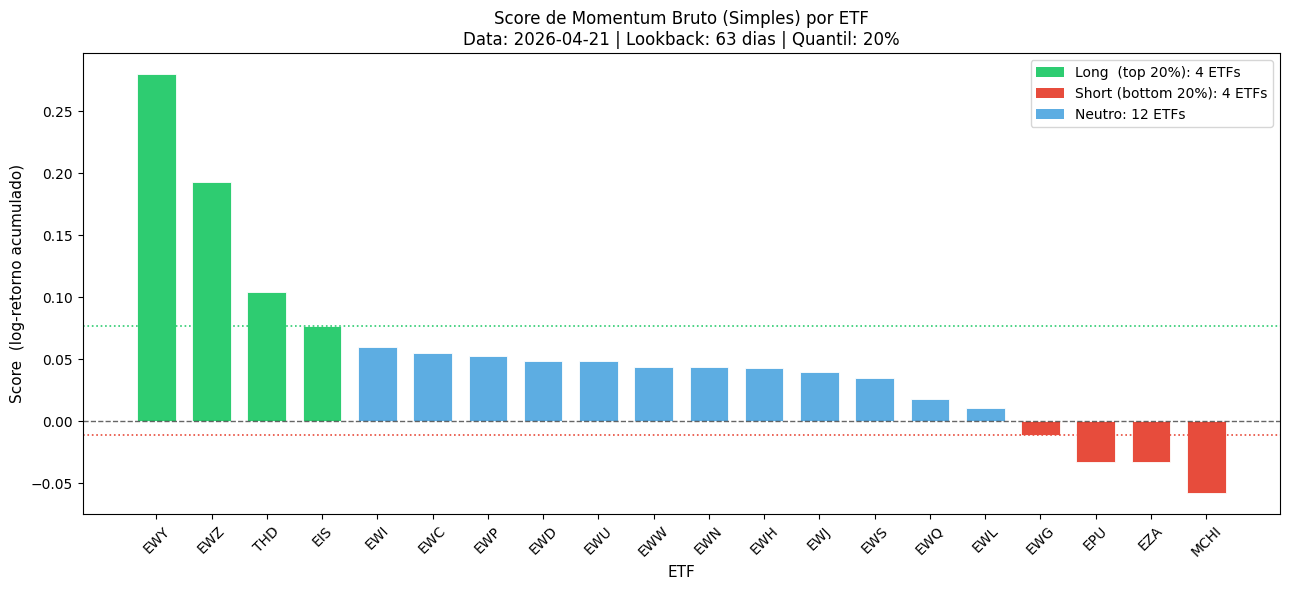

In [9]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(13, 6))

cor_mapa_s = {"Long": "#2ecc71", "Neutro": "#5dade2", "Short": "#e74c3c"}
cores_s    = ranking_simple["Posição"].map(cor_mapa_s)

ax.bar(
    ranking_simple.index, ranking_simple["Score"],
    color=cores_s, edgecolor="white", linewidth=0.6, width=0.7
)
ax.axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.6)

# Linhas de corte dos quantis
long_cutoff_s  = ranking_simple.loc[ranking_simple["Posição"] == "Long",  "Score"].min()
short_cutoff_s = ranking_simple.loc[ranking_simple["Posição"] == "Short", "Score"].max()
if not np.isnan(long_cutoff_s):
    ax.axhline(long_cutoff_s,  color="#2ecc71", linewidth=1.2, linestyle=":")
if not np.isnan(short_cutoff_s):
    ax.axhline(short_cutoff_s, color="#e74c3c", linewidth=1.2, linestyle=":")

ax.set_title(
    f"Score de Momentum Bruto (Simples) por ETF\n"
    f"Data: {snapshot_date_simple.date()} | Lookback: {LOOKBACK} dias | Quantil: {int(QUANTILE*100)}%",
    fontsize=12
)
ax.set_xlabel("ETF", fontsize=11)
ax.set_ylabel("Score  (log-retorno acumulado)", fontsize=11)
ax.tick_params(axis="x", rotation=45)

legend_elementos_s = [
    Patch(facecolor="#2ecc71", label=f"Long  (top {int(QUANTILE*100)}%): {n_long_s} ETFs"),
    Patch(facecolor="#e74c3c", label=f"Short (bottom {int(QUANTILE*100)}%): {n_short_s} ETFs"),
    Patch(facecolor="#5dade2", label=f"Neutro: {n_neut_s} ETFs"),
]
ax.legend(handles=legend_elementos_s, loc="upper right")
plt.tight_layout()
plt.show()


## Análise de Sensibilidade — Estratégia 1 (Simples)

Grade lookback × rebalanceamento com `vol_scaled=False` (retorno acumulado bruto).

Sensibilidade — Estratégia Simples (15 combinações)

Lookback | Rebal |  Sharpe |  Ret.An.% |    MDD%
--------------------------------------------------
      21 |     5 |  -0.086 |     -1.3% |   -49.4%
      21 |    10 |  -0.032 |     -0.5% |   -42.3%
      21 |    21 |  -0.616 |     -8.8% |   -83.0%
      42 |     5 |  -0.330 |     -4.9% |   -66.6%
      42 |    10 |  -0.464 |     -6.8% |   -77.4%
      42 |    21 |  -0.439 |     -6.3% |   -79.4%
      63 |     5 |  -0.173 |     -2.6% |   -67.9%
      63 |    10 |  -0.102 |     -1.5% |   -62.6%
      63 |    21 |  -0.224 |     -3.3% |   -68.6%
     126 |     5 |  -0.054 |     -0.8% |   -53.2%
     126 |    10 |  -0.093 |     -1.4% |   -59.9%
     126 |    21 |  -0.106 |     -1.5% |   -59.4%
     252 |     5 |  -0.392 |     -5.7% |   -73.0%
     252 |    10 |  -0.418 |     -6.0% |   -71.9%
     252 |    21 |  -0.375 |     -5.4% |   -72.9%


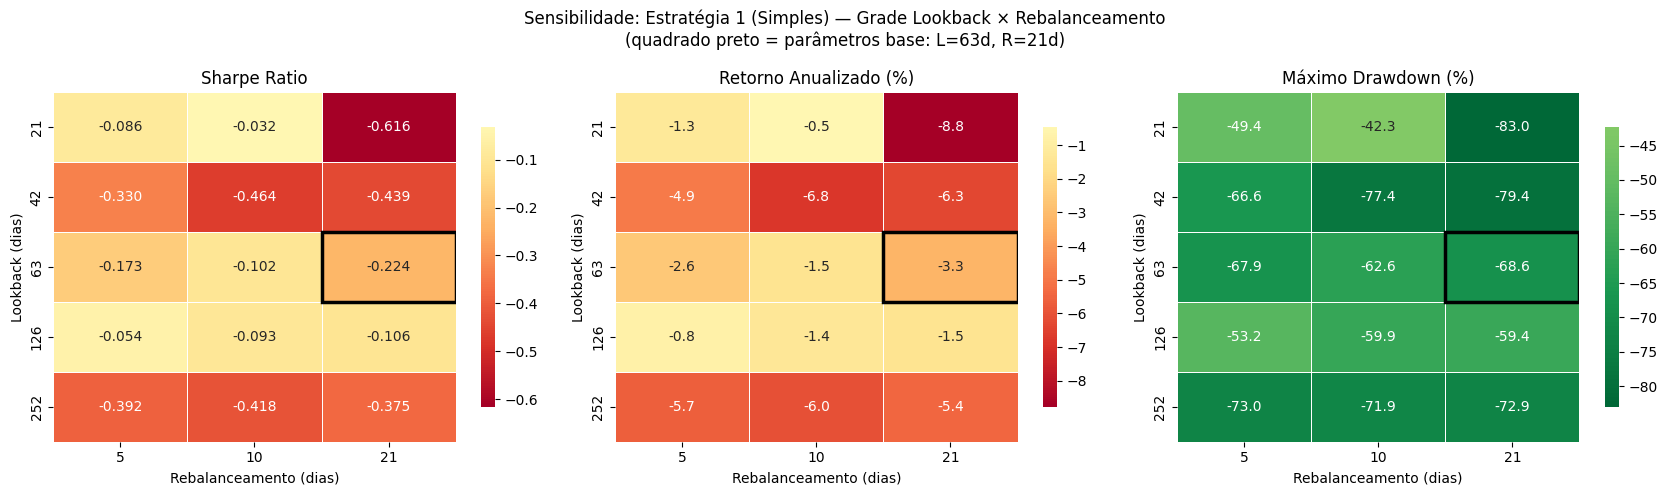

In [10]:
# ── Grade de sensibilidade: Estratégia Simples ────────────────────────────────
s_sharpe_grid = pd.DataFrame(index=lookback_grid, columns=rebal_grid, dtype=float)
s_return_grid = pd.DataFrame(index=lookback_grid, columns=rebal_grid, dtype=float)
s_maxdd_grid  = pd.DataFrame(index=lookback_grid, columns=rebal_grid, dtype=float)
s_sharpe_grid.index.name = s_return_grid.index.name = s_maxdd_grid.index.name = "Lookback (dias)"

print(f"Sensibilidade — Estratégia Simples ({len(lookback_grid)*len(rebal_grid)} combinações)\n")
print(f"{'Lookback':>8} | {'Rebal':>5} | {'Sharpe':>7} | {'Ret.An.%':>9} | {'MDD%':>7}")
print("-" * 50)

for L in lookback_grid:
    for R in rebal_grid:
        if L * 2 >= len(etfs_clean):
            s_sharpe_grid.loc[L, R] = s_return_grid.loc[L, R] = s_maxdd_grid.loc[L, R] = np.nan
            continue
        _, m = run_backtest(etfs_clean, lookback=L, rebal_freq=R, quantile=QUANTILE, vol_scaled=False)
        s_sharpe_grid.loc[L, R] = m["Sharpe Ratio"]
        s_return_grid.loc[L, R] = m["Retorno Anualizado (%)"]
        s_maxdd_grid.loc[L, R]  = m["Máximo Drawdown (%)"]
        print(f"{L:>8} | {R:>5} | {m['Sharpe Ratio']:>+7.3f} | "
              f"{m['Retorno Anualizado (%)']:>+8.1f}% | {m['Máximo Drawdown (%)']:>7.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, data, title, fmt, cmap in zip(
    axes,
    [s_sharpe_grid, s_return_grid, s_maxdd_grid],
    ["Sharpe Ratio", "Retorno Anualizado (%)", "Máximo Drawdown (%)"],
    [".3f", ".1f", ".1f"],
    ["RdYlGn", "RdYlGn", "RdYlGn_r"]
):
    sns.heatmap(data.astype(float), ax=ax, annot=True, fmt=fmt,
                cmap=cmap, center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Rebalanceamento (dias)", fontsize=10)
    ax.set_ylabel("Lookback (dias)", fontsize=10)
    base_row = lookback_grid.index(LOOKBACK)
    base_col = rebal_grid.index(REBAL_FREQ)
    ax.add_patch(plt.Rectangle((base_col, base_row), 1, 1,
                                fill=False, edgecolor="black", linewidth=2.5))

plt.suptitle("Sensibilidade: Estratégia 1 (Simples) — Grade Lookback × Rebalanceamento\n"
             "(quadrado preto = parâmetros base: L=63d, R=21d)", fontsize=12)
plt.tight_layout()
plt.show()

Sub-períodos — Estratégia 1 (Simples)

Sub-período             Ret.An.%   Vol.%   Sharpe     MDD%    (vs Complexa Sharpe)
----------------------------------------------------------------------------------
Pré-COVID (2010–2019)      -6.8%   14.0%   -0.488   -56.4%  ▼ -0.268 vs Complexa (-0.220)
COVID (2020–2021)          -7.7%   14.2%   -0.546   -23.5%  ▼ -0.591 vs Complexa (0.045)
Pós-COVID (2022–hoje)      +0.3%   14.2%    0.023   -30.2%  ▼ -0.437 vs Complexa (0.460)


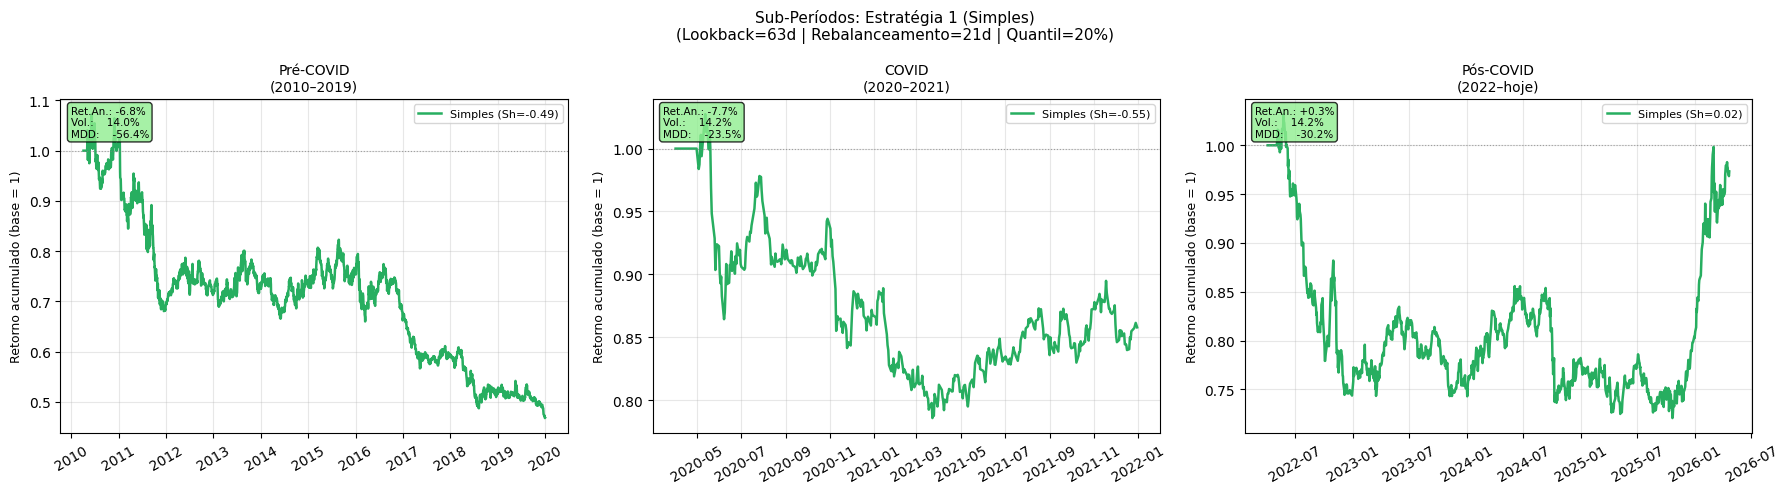

In [11]:
# ── Sub-períodos: Estratégia Simples ──────────────────────────────────────────
print("Sub-períodos — Estratégia 1 (Simples)\n")
print(f"{'Sub-período':<22} {'Ret.An.%':>9} {'Vol.%':>7} {'Sharpe':>8} {'MDD%':>8}  "
      f"{'(vs Complexa Sharpe)':>22}")
print("-" * 82)

resultados_simples_sub = {}

for nome, (start, end) in sub_periodos.items():
    nome_clean = nome.replace("\n", " ")
    prices_sub = etfs_clean.loc[start:end]
    if len(prices_sub) < LOOKBACK + REBAL_FREQ + 5:
        continue

    rets_sub, met_sub = run_backtest(prices_sub, LOOKBACK, REBAL_FREQ, QUANTILE, vol_scaled=False)

    # Complexa no mesmo sub-período (para comparação)
    _, met_cx = run_backtest(prices_sub, LOOKBACK, REBAL_FREQ, QUANTILE, vol_scaled=True)

    resultados_simples_sub[nome] = {"port_returns": rets_sub, "metrics": met_sub}

    delta = met_sub["Sharpe Ratio"] - met_cx["Sharpe Ratio"]
    sinal = "▲" if delta > 0 else "▼"
    print(f"{nome_clean:<22} {met_sub['Retorno Anualizado (%)']:>+8.1f}% "
          f"{met_sub['Volatilidade Anual (%)']:>6.1f}% "
          f"{met_sub['Sharpe Ratio']:>8.3f} "
          f"{met_sub['Máximo Drawdown (%)']:>7.1f}%  "
          f"{sinal} {delta:+.3f} vs Complexa ({met_cx['Sharpe Ratio']:.3f})")

# ── Gráfico de sub-períodos ────────────────────────────────────────────────────
n_sub_s = len(resultados_simples_sub)
fig, axes = plt.subplots(1, n_sub_s, figsize=(6 * n_sub_s, 5), sharey=False)
if n_sub_s == 1:
    axes = [axes]

for ax, (nome, dados) in zip(axes, resultados_simples_sub.items()):
    pr = dados["port_returns"]
    m  = dados["metrics"]
    cum_port = (1 + pr).cumprod()

    ax.plot(cum_port.index, cum_port.values, color="#27ae60", linewidth=1.8,
            label=f"Simples (Sh={m['Sharpe Ratio']:.2f})")
    ax.axhline(1, color="grey", linewidth=0.8, linestyle=":", alpha=0.7)
    ax.set_title(nome, fontsize=10)
    ax.set_ylabel("Retorno acumulado (base = 1)", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=30)

    txt = (f"Ret.An.: {m['Retorno Anualizado (%)']:+.1f}%\n"
           f"Vol.:    {m['Volatilidade Anual (%)']:.1f}%\n"
           f"MDD:    {m['Máximo Drawdown (%)']:.1f}%")
    ax.text(0.02, 0.98, txt, transform=ax.transAxes, fontsize=7.5,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.8))

plt.suptitle("Sub-Períodos: Estratégia 1 (Simples)\n"
             f"(Lookback={LOOKBACK}d | Rebalanceamento={REBAL_FREQ}d | Quantil={int(QUANTILE*100)}%)",
             fontsize=11)
plt.tight_layout()
plt.show()

# Estratégia 2 (Complexa) — Momentum Ajustado ao Risco (Sharpe Momentum)

## Lógica da Estratégia

A estratégia é baseada em **momentum cross-sectional ajustado ao risco**, também chamado de *Risk-Adjusted Momentum* ou *Sharpe Momentum*. O indicador de tendência é:

$$\text{score}_{\text{complexo}}(i,\, t) = \frac{\sum_{k=t-L}^{t} \log r_k(i)}{\sigma_{\text{rolling}}(i,\, t-L \to t)}$$

onde:
- $i$ é o ETF, $t$ é o dia atual, $L$ é a janela de lookback
- O numerador é o retorno acumulado (soma dos log-retornos nos últimos $L$ dias úteis)
- $\sigma_{\text{rolling}}$ é o desvio padrão dos log-retornos nos últimos $L$ dias
- O score é análogo ao **Índice de Sharpe histórico** sobre a janela de lookback

## Por Que Este Indicador É Mais Complexo Que o Simples?

| Critério | Momentum Simples | **Sharpe Momentum (Complexo)** |
|---|---|---|
| Normalização por volatilidade | ✗ | **✓** (comparável entre ativos) |
| Penaliza ativos voláteis | ✗ | **✓** (desvio padrão no denominador) |
| Ranking cross-sectional | ✓ | **✓** |
| Captura tendência | ✓ | **✓** |

## Intuição de Construção

- **Long (top 20%)**: ETFs com alto retorno recente *e* baixa volatilidade → tendência forte e estável
- **Short (bottom 20%)**: ETFs com baixo retorno recente *e/ou* alta volatilidade → tendência fraca ou invertida
- **Neutro (60% do meio)**: sem posição
- Pesos **equal-weight** dentro de cada perna

## Parâmetros Base

| Parâmetro | Valor | Intuição |
|---|---|---|
| Lookback ($L$) | 63 dias úteis (~3 meses) | Captura tendências de médio prazo |
| Rebalanceamento | 21 dias úteis (~1 mês) | Equilíbrio entre reatividade e turnover |
| Quantil | 20% | ~4 ETFs por perna em um universo de 20 |

In [12]:
def compute_scores(prices_df, lookback):
    """
    Calcula o score de momentum ajustado ao risco (Sharpe Momentum) para cada ETF.

    Para cada ativo i no dia t:
        log_ret(i, t)        = log(P[t] / P[t-1])
        cum_log_ret(i, t)    = soma dos log-retornos nos últimos `lookback` dias
                               ≈ log(P[t] / P[t-lookback])
        rolling_vol(i, t)    = desvio padrão dos log-retornos nos últimos `lookback` dias
        score(i, t)          = cum_log_ret(i, t) / rolling_vol(i, t)

    Interpretação:
        score > 0 → tendência de alta (momentum positivo)
        score < 0 → tendência de baixa (momentum negativo)
        |score| alto → tendência forte e/ou volatilidade baixa → sinal mais confiável

    Sem look-ahead bias: score(i, t) utiliza apenas dados até o dia t (rolling window).
    """
    log_ret     = np.log(prices_df / prices_df.shift(1))
    cum_log_ret = log_ret.rolling(lookback).sum()    # retorno acumulado (soma log-retornos)
    rolling_vol = log_ret.rolling(lookback).std()    # volatilidade rolling
    return cum_log_ret / rolling_vol                 # score Sharpe-like


# ── Calcula scores para todos os ETFs ─────────────────────────────────────────
scores = compute_scores(etfs_clean, LOOKBACK)

print(f"Scores de momentum calculados com janela de {LOOKBACK} dias úteis.")
print(f"\nSnapshot dos scores (últimas 3 datas com dados):")
print(scores.dropna(how='all').tail(3).round(3).to_string())

Scores de momentum calculados com janela de 63 dias úteis.

Snapshot dos scores (últimas 3 datas com dados):
Ticker        EIS    EPU    EWC    EWD    EWG    EWH    EWI    EWJ    EWL    EWN    EWP    EWQ    EWS    EWU    EWW    EWY     EWZ    EZA   MCHI    THD
Date                                                                                                                                                   
2026-04-17  5.107  0.970  4.983  3.865 -0.080  2.603  4.627  3.298  2.539  2.504  4.433  2.173  4.203  5.594  4.236  8.680  10.480  0.437 -5.352  9.339
2026-04-20  4.665  0.988  5.488  3.622 -0.560  3.924  4.434  2.665  2.618  2.182  3.644  1.890  4.205  4.990  3.986  7.968  10.952  0.462 -4.091  7.774
2026-04-21  4.644 -1.244  4.619  2.998 -0.779  3.968  3.993  2.409  0.868  2.748  3.194  1.306  3.038  3.943  2.288  7.644   9.631 -1.212 -4.472  5.504


In [13]:
# ── Gera snapshot da tabela de classificação (Estratégia 2 — Complexa) ────────
ranking_table, snapshot_date = build_ranking_snapshot(scores, QUANTILE)

n_long  = (ranking_table["Posição"] == "Long").sum()
n_short = (ranking_table["Posição"] == "Short").sum()
n_neut  = (ranking_table["Posição"] == "Neutro").sum()

print(f"{'='*55}")
print(f"  TABELA DE CLASSIFICAÇÃO — {snapshot_date.date()}")
print(f"{'='*55}")
print(f"  Lookback         : {LOOKBACK} dias úteis")
print(f"  Quantil por perna: {int(QUANTILE*100)}%")
print(f"  Long  (top  {int(QUANTILE*100)}%): {n_long}  ETFs")
print(f"  Short (bot. {int(QUANTILE*100)}%): {n_short}  ETFs")
print(f"  Neutro           : {n_neut}  ETFs")
print(f"{'='*55}")
print()
print(ranking_table.to_string())


  TABELA DE CLASSIFICAÇÃO — 2026-04-21
  Lookback         : 63 dias úteis
  Quantil por perna: 20%
  Long  (top  20%): 4  ETFs
  Short (bot. 20%): 4  ETFs
  Neutro           : 12  ETFs

        Score  Rank Posição
Ticker                     
EWZ     9.631     1    Long
EWY     7.644     2    Long
THD     5.504     3    Long
EIS     4.644     4    Long
EWC     4.619     5  Neutro
EWI     3.993     6  Neutro
EWH     3.968     7  Neutro
EWU     3.943     8  Neutro
EWP     3.194     9  Neutro
EWS     3.038    10  Neutro
EWD     2.998    11  Neutro
EWN     2.748    12  Neutro
EWJ     2.409    13  Neutro
EWW     2.288    14  Neutro
EWQ     1.306    15  Neutro
EWL     0.868    16  Neutro
EWG    -0.779    17   Short
EZA    -1.212    18   Short
EPU    -1.244    19   Short
MCHI   -4.472    20   Short


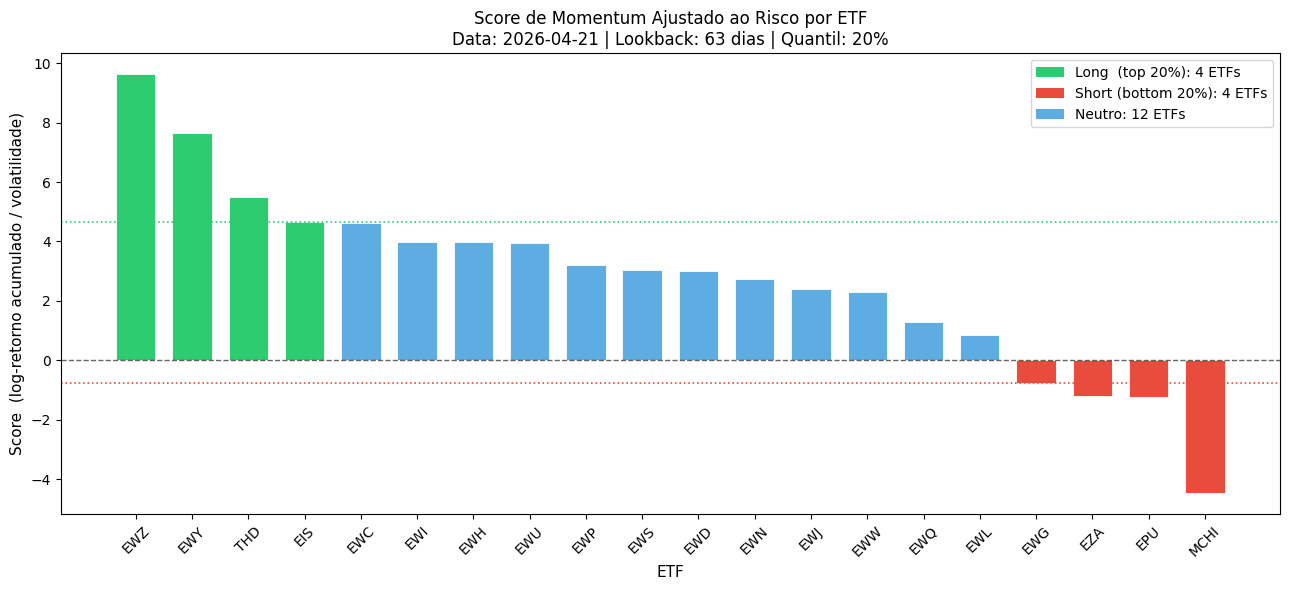

In [14]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(13, 6))

cor_mapa = {"Long": "#2ecc71", "Neutro": "#5dade2", "Short": "#e74c3c"}
cores    = ranking_table["Posição"].map(cor_mapa)

ax.bar(
    ranking_table.index, ranking_table["Score"],
    color=cores, edgecolor="white", linewidth=0.6, width=0.7
)
ax.axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.6)

# Linhas de corte dos quantis
long_cutoff  = ranking_table.loc[ranking_table["Posição"] == "Long",  "Score"].min()
short_cutoff = ranking_table.loc[ranking_table["Posição"] == "Short", "Score"].max()
if not np.isnan(long_cutoff):
    ax.axhline(long_cutoff,  color="#2ecc71", linewidth=1.2, linestyle=":")
if not np.isnan(short_cutoff):
    ax.axhline(short_cutoff, color="#e74c3c", linewidth=1.2, linestyle=":")

ax.set_title(
    f"Score de Momentum Ajustado ao Risco por ETF\n"
    f"Data: {snapshot_date.date()} | Lookback: {LOOKBACK} dias | Quantil: {int(QUANTILE*100)}%",
    fontsize=12
)
ax.set_xlabel("ETF", fontsize=11)
ax.set_ylabel("Score  (log-retorno acumulado / volatilidade)", fontsize=11)
ax.tick_params(axis="x", rotation=45)

legend_elementos = [
    Patch(facecolor="#2ecc71", label=f"Long  (top {int(QUANTILE*100)}%): {n_long} ETFs"),
    Patch(facecolor="#e74c3c", label=f"Short (bottom {int(QUANTILE*100)}%): {n_short} ETFs"),
    Patch(facecolor="#5dade2", label=f"Neutro: {n_neut} ETFs"),
]
ax.legend(handles=legend_elementos, loc="upper right")
plt.tight_layout()
plt.show()

### Validação do Passo 1 — Estratégia Complexa

**O que verificar:**
1. **Tabela de classificação**: deve ter exatamente `⌈20 × 20%⌉ = 4` ETFs em cada perna (Long e Short).
2. **Scores**: valores positivos indicam tendência de alta, negativos indicam tendência de baixa. Ativos neutros têm scores próximos de zero.
3. **Gráfico de barras**: barras verdes (Long) à esquerda com scores mais altos, barras vermelhas (Short) à direita com scores mais baixos. Barras azuis (Neutro) no meio, próximas de zero.
4. **Sem NaN**: confirmar que `len(ranking_table)` é igual ao número de ETFs com histórico suficiente para o lookback de 63 dias.

Se essas condições forem atendidas, o indicador de tendência está calculado corretamente e sem look-ahead bias. Avançamos para o Passo 2.


# Passo 2 — Alocação e Backtesting

## Premissas do Backtest

| Premissa | Valor / Detalhe |
|---|---|
| Custos de transação | **Nenhum** (simplificação) |
| Slippage | **Nenhum** (execução no preço de fechamento) |
| Dados de preço | Fechamento ajustado (`auto_adjust=True`): incorpora dividendos e splits |
| Cotas fracionárias | **Permitidas** (sem restrição de lote mínimo) |
| Venda a descoberto | **Permitida** sem custo de *stock lending* |
| Taxa livre de risco | **0% a.a.** (simplificação; análise de Sharpe conservadora) |
| Geração de sinal | Fechamento do dia $t$ → posição aberta a partir do dia $t+1$ (**sem look-ahead bias**) |
| Alocação | **Equal-weight** dentro de cada perna: long = $+1/N_L$, short = $-1/N_S$ |
| Rebalanceamento | A cada **REBAL_FREQ** dias úteis |

## Métricas de Desempenho

- **Retorno Total (%)**: valor final da carteira − 1
- **Retorno Anualizado (%)**: $\overline{r}_{\text{diário}} \times 252$
- **Volatilidade Anual (%)**: $\sigma_{\text{diária}} \times \sqrt{252}$
- **Sharpe Ratio**: $(\text{Ret. An.} - r_f) / \text{Vol. An.}$
- **Máximo Drawdown (%)**: maior queda do pico ao vale
- **Calmar Ratio**: $\text{Ret. An.} / |\text{MDD}|$

In [15]:
# ── Executa o backtest com os parâmetros base ─────────────────────────────────
port_returns, metrics = run_backtest(
    prices_df  = etfs_clean,
    lookback   = LOOKBACK,
    rebal_freq = REBAL_FREQ,
    quantile   = QUANTILE,
    rf_annual  = 0.0,
)

# ── Prepara benchmark (ACWI) ──────────────────────────────────────────────────
bmark_returns = bmark_series.pct_change().dropna()
bmark_returns = bmark_returns.reindex(port_returns.index)
bmark_returns.name = "ACWI"

port_aligned  = port_returns.reindex(bmark_returns.dropna().index)
bmark_metrics = _compute_metrics(bmark_returns.dropna())

# ── Tabela 2-vias: Estratégia 2 vs ACWI ──────────────────────────────────────
metrics_df = pd.DataFrame({
    "Estratégia 2 (Complexa)": metrics,
    "Benchmark (ACWI)":        bmark_metrics,
}).T

print("=" * 65)
print("    DESEMPENHO — Estratégia 2 (Complexa) | Período Completo")
print("=" * 65)
print(metrics_df.to_string())

# ── Tabela 3-vias: Simples vs Complexa vs ACWI ────────────────────────────────
comp_df = pd.DataFrame({
    "Estratégia 1 (Simples)":  simple_metrics,
    "Estratégia 2 (Complexa)": metrics,
    "Benchmark (ACWI)":        bmark_metrics,
}).T

print("\n" + "=" * 70)
print("    COMPARAÇÃO GERAL — Simples vs Complexa vs ACWI")
print("=" * 70)
print(comp_df.to_string())
print()
print(f"Parâmetros: Lookback={LOOKBACK}d | Rebalanceamento={REBAL_FREQ}d | Quantil={int(QUANTILE*100)}%")

    DESEMPENHO — Estratégia 2 (Complexa) | Período Completo
                         Retorno Total (%)  Retorno Anualizado (%)  Volatilidade Anual (%)  Sharpe Ratio  Máximo Drawdown (%)  Calmar Ratio
Estratégia 2 (Complexa)              -7.44                    0.38                   13.14         0.029               -54.79         0.007
Benchmark (ACWI)                    363.51                   11.08                   17.30         0.640               -33.53         0.330

    COMPARAÇÃO GERAL — Simples vs Complexa vs ACWI
                         Retorno Total (%)  Retorno Anualizado (%)  Volatilidade Anual (%)  Sharpe Ratio  Máximo Drawdown (%)  Calmar Ratio
Estratégia 1 (Simples)              -50.07                   -3.27                   14.59        -0.224               -68.56        -0.048
Estratégia 2 (Complexa)              -7.44                    0.38                   13.14         0.029               -54.79         0.007
Benchmark (ACWI)                    363.51      

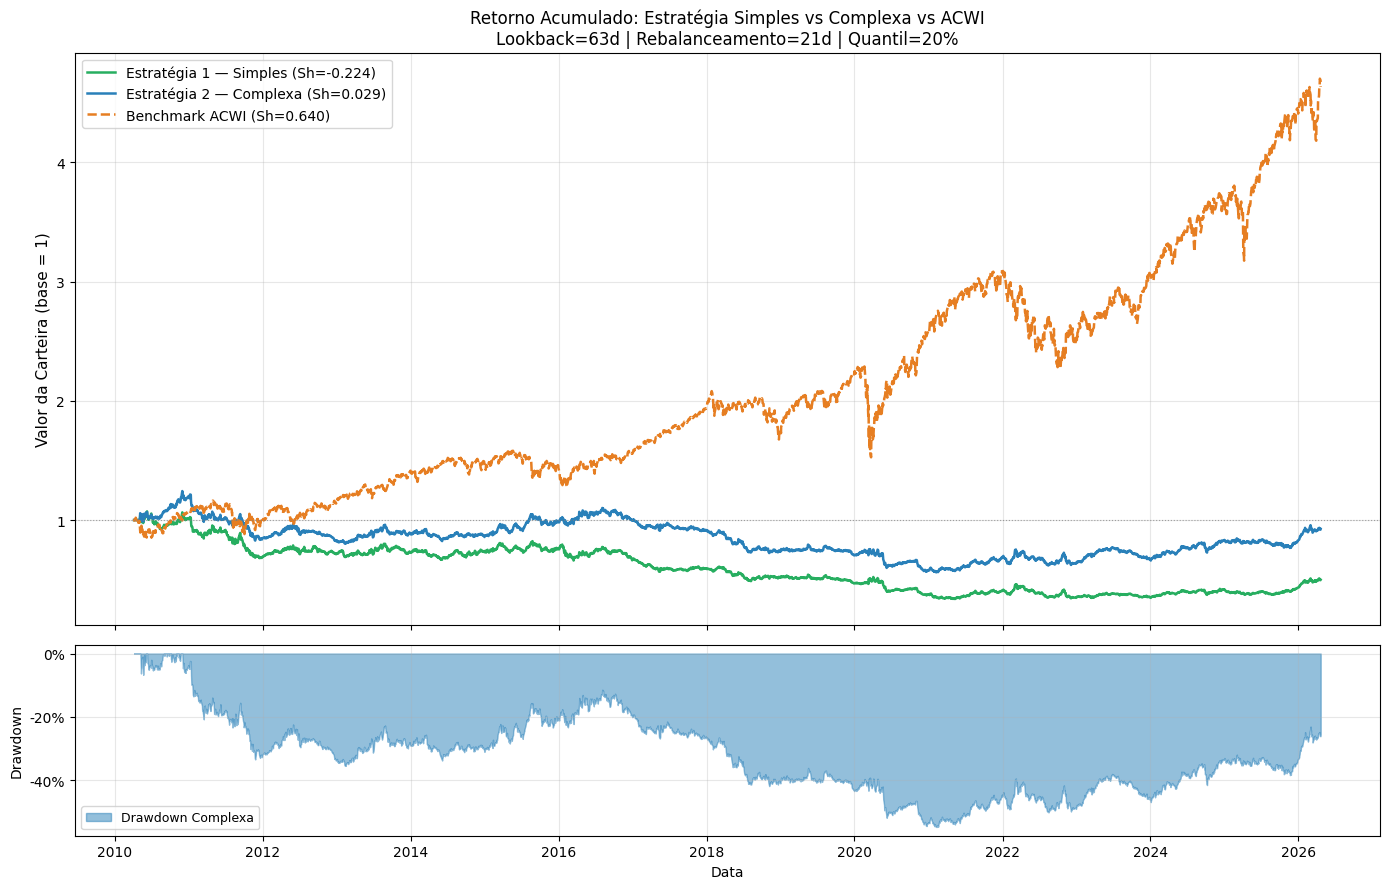

In [16]:
fig, axes = plt.subplots(
    2, 1, figsize=(14, 9),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True
)

# ── Alinha todas as séries ao mesmo índice ─────────────────────────────────────
common_idx     = port_aligned.index.intersection(simple_port_returns.index)
cumret_port    = (1 + port_aligned.reindex(common_idx)).cumprod()
cumret_simple  = (1 + simple_port_returns.reindex(common_idx)).cumprod()
cumret_bmark   = (1 + bmark_returns.reindex(common_idx).fillna(0)).cumprod()

# ── Subplot 1: Retorno acumulado ───────────────────────────────────────────────
axes[0].plot(cumret_simple.index, cumret_simple.values,
             label=f"Estratégia 1 — Simples (Sh={simple_metrics['Sharpe Ratio']:.3f})",
             color="#27ae60", linewidth=1.8)
axes[0].plot(cumret_port.index, cumret_port.values,
             label=f"Estratégia 2 — Complexa (Sh={metrics['Sharpe Ratio']:.3f})",
             color="#2980b9", linewidth=1.8)
axes[0].plot(cumret_bmark.index, cumret_bmark.values,
             label=f"Benchmark ACWI (Sh={bmark_metrics['Sharpe Ratio']:.3f})",
             color="#e67e22", linewidth=1.8, linestyle="--")
axes[0].axhline(1, color="grey", linewidth=0.8, linestyle=":", alpha=0.7)
axes[0].set_ylabel("Valor da Carteira (base = 1)", fontsize=11)
axes[0].set_title(
    "Retorno Acumulado: Estratégia Simples vs Complexa vs ACWI\n"
    f"Lookback={LOOKBACK}d | Rebalanceamento={REBAL_FREQ}d | Quantil={int(QUANTILE*100)}%",
    fontsize=12
)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# ── Subplot 2: Drawdown da estratégia complexa ────────────────────────────────
rolling_max   = cumret_port.cummax()
drawdown_port = (cumret_port / rolling_max) - 1

axes[1].fill_between(drawdown_port.index, drawdown_port.values, 0,
                     color="#2980b9", alpha=0.5, label="Drawdown Complexa")
axes[1].set_ylabel("Drawdown", fontsize=10)
axes[1].set_xlabel("Data", fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.show()

# Passo 3 — Análise de Sensibilidade

O objetivo é avaliar a **robustez** da estratégia frente a variações nos parâmetros e em diferentes regimes de mercado.

## Duas dimensões de análise

### 3A — Grade Lookback × Rebalanceamento
Testamos combinações de:
- **Janela de lookback** ($L$): `[21, 42, 63, 126, 252]` dias úteis
  - Curto (21d): captura tendências de curto prazo; mais ruidoso
  - Médio (63d): nosso baseline; equilíbrio ruído/sinal
  - Longo (252d): tendências de longo prazo; mais lento para reagir
- **Frequência de rebalanceamento** ($R$): `[5, 10, 21]` dias úteis
  - 5d (semanal): maior turnover; mais reativo
  - 21d (mensal): nosso baseline; menor turnover

Para cada combinação ($L$, $R$) rodamos o backtest completo e coletamos Sharpe Ratio, Retorno Anualizado e Máximo Drawdown.

### 3B — Sub-períodos
Testamos o baseline ($L=63$, $R=21$) em três janelas temporais distintas:

| Sub-período | Datas | Características |
|---|---|---|
| Pré-COVID | 2010–2019 | Bull market prolongado, baixa volatilidade |
| COVID | 2020–2021 | Crash rápido + recuperação em V, alta volatilidade |
| Pós-COVID | 2022–hoje | Divergência entre mercados (juros, energia, EM vs DM) |

In [17]:
# ── 3A: Grade de sensibilidade Lookback × Rebalanceamento ─────────────────────
# lookback_grid e rebal_grid foram atualizados pela pré-seleção de parâmetros
# e já incluem o valor ótimo selecionado (LOOKBACK, REBAL_FREQ).

sharpe_grid = pd.DataFrame(index=lookback_grid, columns=rebal_grid, dtype=float)
return_grid = pd.DataFrame(index=lookback_grid, columns=rebal_grid, dtype=float)
maxdd_grid  = pd.DataFrame(index=lookback_grid, columns=rebal_grid, dtype=float)

sharpe_grid.index.name  = "Lookback (dias)"
return_grid.index.name  = "Lookback (dias)"
maxdd_grid.index.name   = "Lookback (dias)"

n_combinacoes = len(lookback_grid) * len(rebal_grid)
print(f"Executando análise de sensibilidade: {n_combinacoes} combinações...\n")
print(f"{'Lookback':>8} | {'Rebal':>5} | {'Sharpe':>7} | {'Ret.An.%':>9} | {'MDD%':>7}")
print("-" * 50)

for L in lookback_grid:
    for R in rebal_grid:
        # Precisa de pelo menos 2× lookback dias para ter resultados significativos
        if L * 2 >= len(etfs_clean):
            sharpe_grid.loc[L, R] = np.nan
            return_grid.loc[L, R] = np.nan
            maxdd_grid.loc[L, R]  = np.nan
            print(f"{L:>8} | {R:>5} | {'N/A':>7} | {'N/A':>9} | {'N/A':>7}")
            continue

        _, m = run_backtest(etfs_clean, lookback=L, rebal_freq=R, quantile=QUANTILE)
        sharpe_grid.loc[L, R] = m["Sharpe Ratio"]
        return_grid.loc[L, R] = m["Retorno Anualizado (%)"]
        maxdd_grid.loc[L, R]  = m["Máximo Drawdown (%)"]
        print(f"{L:>8} | {R:>5} | {m['Sharpe Ratio']:>+7.3f} | "
              f"{m['Retorno Anualizado (%)']:>+8.1f}% | {m['Máximo Drawdown (%)']:>7.1f}%")

print("\nAnálise de sensibilidade concluída.")


Executando análise de sensibilidade: 15 combinações...

Lookback | Rebal |  Sharpe |  Ret.An.% |    MDD%
--------------------------------------------------
      21 |     5 |  +0.181 |     +2.4% |   -36.0%
      21 |    10 |  +0.040 |     +0.5% |   -29.1%
      21 |    21 |  -0.504 |     -6.4% |   -74.2%
      42 |     5 |  -0.316 |     -4.2% |   -61.9%
      42 |    10 |  -0.310 |     -4.2% |   -63.6%
      42 |    21 |  -0.342 |     -4.5% |   -70.5%
      63 |     5 |  +0.124 |     +1.6% |   -41.0%
      63 |    10 |  +0.132 |     +1.8% |   -43.9%
      63 |    21 |  +0.029 |     +0.4% |   -54.8%
     126 |     5 |  +0.169 |     +2.3% |   -35.9%
     126 |    10 |  +0.028 |     +0.4% |   -44.2%
     126 |    21 |  +0.126 |     +1.7% |   -40.9%
     252 |     5 |  -0.169 |     -2.3% |   -60.5%
     252 |    10 |  -0.224 |     -3.1% |   -61.9%
     252 |    21 |  -0.117 |     -1.6% |   -52.5%

Análise de sensibilidade concluída.


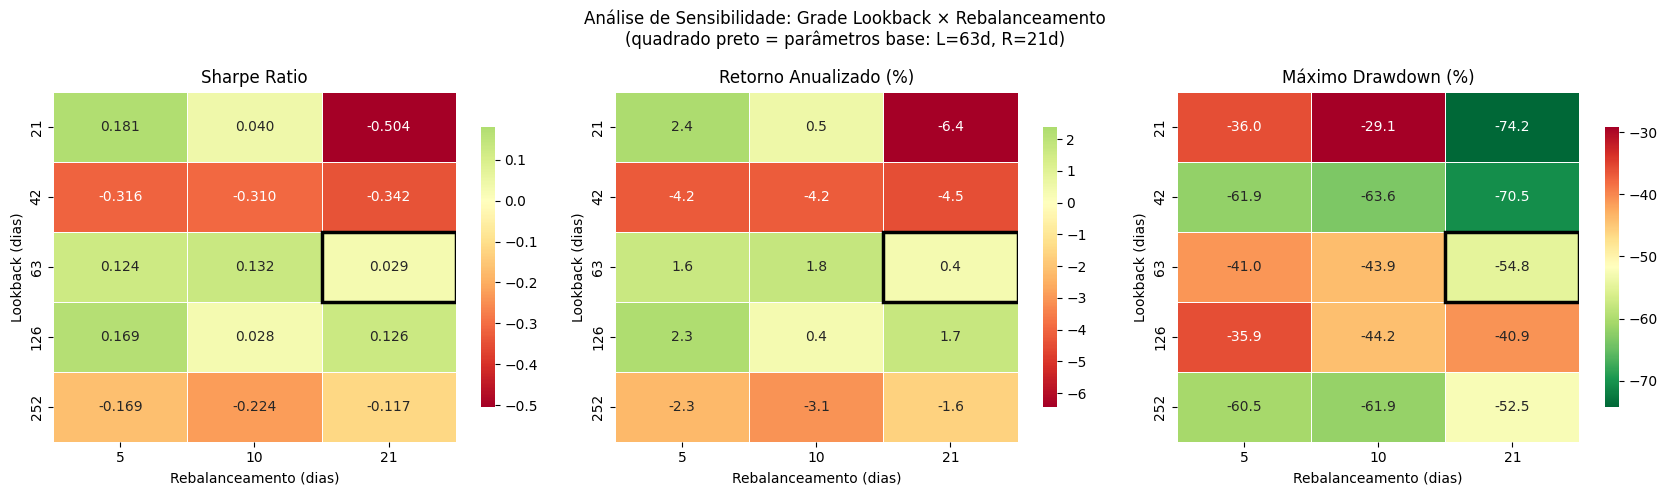

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Heatmap 1: Sharpe Ratio ────────────────────────────────────────────────────
sns.heatmap(
    sharpe_grid.astype(float),
    ax=axes[0], annot=True, fmt=".3f",
    cmap="RdYlGn", center=0, linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
axes[0].set_title("Sharpe Ratio", fontsize=12)
axes[0].set_xlabel("Rebalanceamento (dias)", fontsize=10)
axes[0].set_ylabel("Lookback (dias)", fontsize=10)

# Destaca o parâmetro base
base_row = lookback_grid.index(LOOKBACK)
base_col = rebal_grid.index(REBAL_FREQ)
axes[0].add_patch(plt.Rectangle(
    (base_col, base_row), 1, 1,
    fill=False, edgecolor="black", linewidth=2.5, label="Parâm. base"
))

# ── Heatmap 2: Retorno Anualizado ─────────────────────────────────────────────
sns.heatmap(
    return_grid.astype(float),
    ax=axes[1], annot=True, fmt=".1f",
    cmap="RdYlGn", center=0, linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
axes[1].set_title("Retorno Anualizado (%)", fontsize=12)
axes[1].set_xlabel("Rebalanceamento (dias)", fontsize=10)
axes[1].set_ylabel("Lookback (dias)", fontsize=10)
axes[1].add_patch(plt.Rectangle(
    (base_col, base_row), 1, 1,
    fill=False, edgecolor="black", linewidth=2.5
))

# ── Heatmap 3: Máximo Drawdown ────────────────────────────────────────────────
sns.heatmap(
    maxdd_grid.astype(float),
    ax=axes[2], annot=True, fmt=".1f",
    cmap="RdYlGn_r", linewidths=0.5,       # invertido: MDD menor é melhor
    cbar_kws={"shrink": 0.8}
)
axes[2].set_title("Máximo Drawdown (%)", fontsize=12)
axes[2].set_xlabel("Rebalanceamento (dias)", fontsize=10)
axes[2].set_ylabel("Lookback (dias)", fontsize=10)
axes[2].add_patch(plt.Rectangle(
    (base_col, base_row), 1, 1,
    fill=False, edgecolor="black", linewidth=2.5
))

plt.suptitle(
    "Análise de Sensibilidade: Grade Lookback × Rebalanceamento\n"
    "(quadrado preto = parâmetros base: L=63d, R=21d)",
    fontsize=12
)
plt.tight_layout()
plt.show()

In [19]:
# ── 3B: Análise por sub-períodos (parâmetros base fixos) ──────────────────────
# sub_periodos e bmark_series já definidos na célula de parâmetros
resultados_subperiodo = {}

print(f"{'Sub-período':<22} {'Ret.An.%':>9} {'Vol.%':>7} {'Sharpe':>8} {'MDD%':>8}  "
      f"{'(vs ACWI Sharpe)':>18}")
print("-" * 78)

for nome, (start, end) in sub_periodos.items():
    nome_clean = nome.replace("\n", " ")
    prices_sub = etfs_clean.loc[start:end]

    if len(prices_sub) < LOOKBACK + REBAL_FREQ + 5:
        print(f"{nome_clean:<22} — dados insuficientes para este período")
        continue

    rets_sub, met_sub = run_backtest(prices_sub, LOOKBACK, REBAL_FREQ, QUANTILE)

    bmark_sub         = bmark_series.loc[start:end].pct_change().dropna()
    bmark_sub_aligned = bmark_sub.reindex(rets_sub.index)
    bmark_met         = _compute_metrics(bmark_sub_aligned.dropna())

    resultados_subperiodo[nome] = {
        "port_returns":  rets_sub,
        "bmark_returns": bmark_sub_aligned,
        "metrics":       met_sub,
        "bmark_metrics": bmark_met,
    }

    m  = met_sub
    bm = bmark_met
    delta_sharpe = m["Sharpe Ratio"] - bm["Sharpe Ratio"]
    sinal = "▲" if delta_sharpe > 0 else "▼"
    print(f"{nome_clean:<22} {m['Retorno Anualizado (%)']:>+8.1f}% "
          f"{m['Volatilidade Anual (%)']:>6.1f}% "
          f"{m['Sharpe Ratio']:>8.3f} "
          f"{m['Máximo Drawdown (%)']:>7.1f}%  "
          f"{sinal} {delta_sharpe:+.3f} vs ACWI ({bm['Sharpe Ratio']:.3f})")

print("\n(▲ = Sharpe da estratégia > Sharpe ACWI no sub-período)")

Sub-período             Ret.An.%   Vol.%   Sharpe     MDD%    (vs ACWI Sharpe)
------------------------------------------------------------------------------
Pré-COVID (2010–2019)      -2.8%   12.7%   -0.220   -43.4%  ▼ -0.820 vs ACWI (0.600)
COVID (2020–2021)          +0.6%   13.1%    0.045   -16.6%  ▼ -2.128 vs ACWI (2.173)
Pós-COVID (2022–hoje)      +5.9%   12.7%    0.460   -17.6%  ▼ -0.324 vs ACWI (0.784)

(▲ = Sharpe da estratégia > Sharpe ACWI no sub-período)


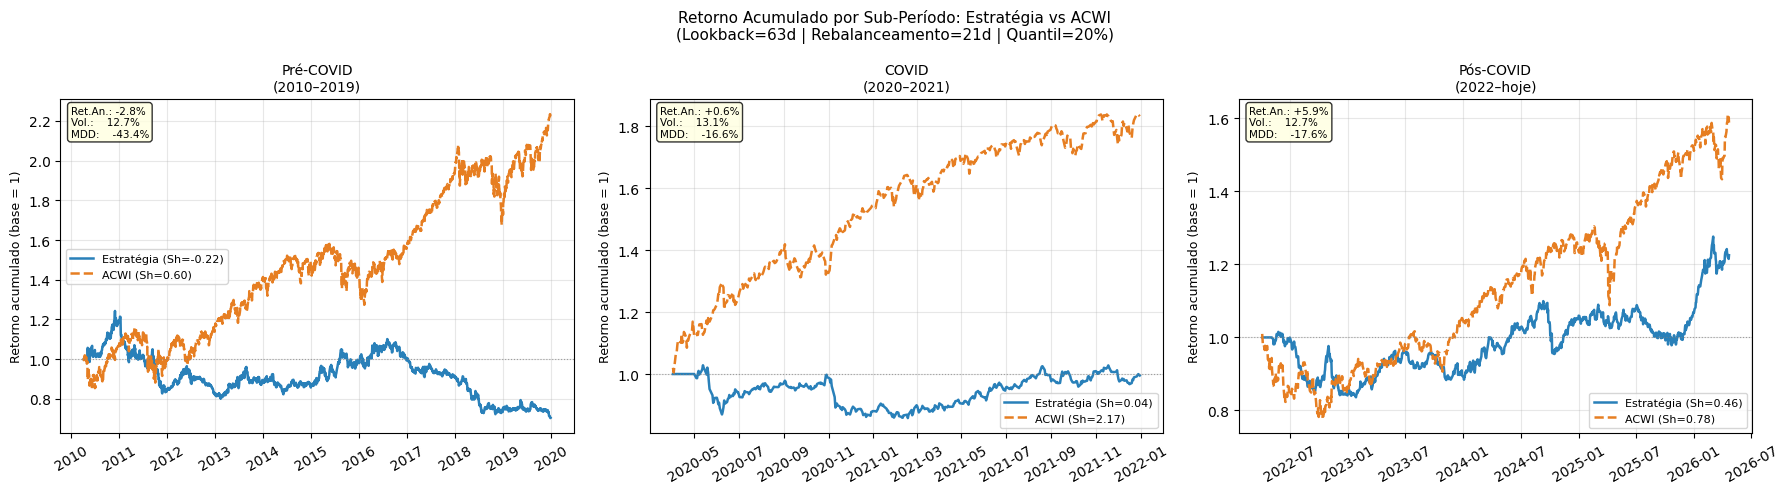

In [20]:
n_sub = len(resultados_subperiodo)
if n_sub == 0:
    print("Nenhum sub-período com dados suficientes.")
else:
    fig, axes = plt.subplots(1, n_sub, figsize=(6 * n_sub, 5), sharey=False)
    if n_sub == 1:
        axes = [axes]

    for ax, (nome, dados) in zip(axes, resultados_subperiodo.items()):
        pr = dados["port_returns"]
        br = dados["bmark_returns"].dropna()
        m  = dados["metrics"]
        bm = dados["bmark_metrics"]

        # Alinha datas
        common_idx = pr.index.intersection(br.index)
        cum_port   = (1 + pr.reindex(common_idx)).cumprod()
        cum_bmark  = (1 + br.reindex(common_idx)).cumprod()

        ax.plot(cum_port.index,  cum_port.values,
                label=f"Estratégia (Sh={m['Sharpe Ratio']:.2f})",
                color="#2980b9", linewidth=1.8)
        ax.plot(cum_bmark.index, cum_bmark.values,
                label=f"ACWI (Sh={bm['Sharpe Ratio']:.2f})",
                color="#e67e22", linewidth=1.8, linestyle="--")
        ax.axhline(1, color="grey", linewidth=0.8, linestyle=":", alpha=0.7)

        ax.set_title(nome, fontsize=10)
        ax.set_ylabel("Retorno acumulado (base = 1)", fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        ax.tick_params(axis="x", rotation=30)

        # Mini-tabela de métricas como texto dentro do gráfico
        txt = (
            f"Ret.An.: {m['Retorno Anualizado (%)']:+.1f}%\n"
            f"Vol.:    {m['Volatilidade Anual (%)']:.1f}%\n"
            f"MDD:    {m['Máximo Drawdown (%)']:.1f}%"
        )
        ax.text(
            0.02, 0.98, txt,
            transform=ax.transAxes, fontsize=7.5,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8)
        )

    plt.suptitle(
        "Retorno Acumulado por Sub-Período: Estratégia vs ACWI\n"
        f"(Lookback={LOOKBACK}d | Rebalanceamento={REBAL_FREQ}d | Quantil={int(QUANTILE*100)}%)",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

## Interpretação dos Resultados

### 3A — Grade Lookback × Rebalanceamento

**Leitura do heatmap de Sharpe Ratio:**

- **Regiões verdes** (Sharpe alto): indicam combinações robustas de parâmetros. Se a estratégia é genuinamente lucrativa, o sinal do Sharpe deve ser consistentemente positivo para a maioria das combinações.
- **Regiões vermelhas** (Sharpe negativo): indicam que naqueles regimes de lookback/rebalanceamento a estratégia **destrói valor**, o que é um sinal de alerta.
- **Sensibilidade ao lookback**: geralmente, janelas muito curtas (21d) são mais suscetíveis a ruído de mercado; janelas muito longas (252d) perdem reatividade. O sweet spot suele estar na faixa de **42–126 dias**.
- **Sensibilidade ao rebalanceamento**: rebalanceamento mais frequente não necessariamente melhora o Sharpe — aumenta o turnover (e custos em cenários reais).

### 3B — Sub-períodos

| Sub-período | Expectativa para Momentum |
|---|---|
| **Pré-COVID (2010–2019)** | Favorável: mercados em tendência clara, alta dispersão entre países (Eurozona vs EM vs US) |
| **COVID (2020–2021)** | Desfavorável: crash de Mar/2020 seguido de recuperação em V invertem posições abruptamente (momentum crash) |
| **Pós-COVID (2022–hoje)** | Misto: alta volatilidade, mas divergências estruturais entre mercados (energia, taxas, China vs Índia) podem favorecer cross-sectional momentum |

### Limitações e Próximos Passos

1. **Ausência de custos de transação**: com rebalanceamento semanal (R=5d), o turnover seria alto e os custos reais reduziriam o Sharpe significativamente.
2. **Universo restrito (20 ETFs)**: com apenas ~4 ETFs por perna, a diversificação é limitada e o risco idiossincrático é alto.
3. **Período único de calibração**: parâmetros testados no mesmo período histórico podem sofrer de *data snooping*. Uma abordagem walk-forward seria mais robusta.
4. **Benchmark sintético**: uma próxima evolução é usar um benchmark de equal-vol do próprio universo (como indicado no comentário do código original) para comparação mais justa.
